In [1]:
import pandas as pd
import numpy as np
from astropy.table import Table
import pickle
import matplotlib.pyplot as plt

In [2]:
def load_predictions(file_path):
    """Load the pickle file"""
    data = []
    with open(file_path, 'rb') as f:
        while True:
            try:
                data.append(pickle.load(f))
            except EOFError:
                break
    return data

def simple_injection_recovery(catalog_file, predictions_file, time_window=0.5/24, threshold=0.5):
    """
    Simple injection-recovery analysis for both comets and planets.
    
    Parameters:
    -----------
    catalog_file : str
        Path to .txt file with injections (contains both tpeak and planet_tpeak columns)
    predictions_file : str  
        Path to .pkl file with predictions
    time_window : float
        Time window in days (default 0.5/24 = 0.5 hours)
    threshold : float
        Probability threshold for recovery
        
    Returns:
    --------
    results_df : pd.DataFrame
        DataFrame with recovery results for both comets and planets
    """
    
    # Load injection catalog
    catalog = pd.read_csv(catalog_file, sep=' ')
    
    # Load predictions
    predictions_data = load_predictions(predictions_file)
    pred_df = pd.DataFrame(load_predictions(predictions_file))

    # Merge on TIC ID
    pred_df.ID = pd.to_numeric(pred_df.ID)
    merged = catalog.merge(pred_df, left_on='TIC', right_on='ID', how='inner')
    
    print(f"Found {len(merged)} targets with both injections and predictions")
    
    # Check recovery for each injection
    comet_recovered = []
    comet_max_probs = []
    planet_recovered = []  # <- New line
    planet_max_probs = []  # <- New line
    
    for idx, row in merged.iterrows():
        comet_injection_time = row['tpeak']
        planet_injection_time = row['planet_tpeak']  # <- New line
        
        # Extract time and prediction arrays from the row
        time_array = np.array(row['time'])
        pred_array = np.array(row['predictions'])
        
        # Check COMET injection
        comet_time_mask = np.abs(time_array - comet_injection_time) <= time_window
        if np.any(comet_time_mask):
            comet_max_prob = np.max(pred_array[comet_time_mask])
            comet_max_probs.append(comet_max_prob)
            comet_recovered.append(1 if comet_max_prob >= threshold else 0)
        else:
            comet_recovered.append(0)
            comet_max_probs.append(0.0)
        
        # Check PLANET injection  # <- New block
        planet_time_mask = np.abs(time_array - planet_injection_time) <= time_window
        if np.any(planet_time_mask):
            planet_max_prob = np.max(pred_array[planet_time_mask])
            planet_max_probs.append(planet_max_prob)
            planet_recovered.append(1 if planet_max_prob >= threshold else 0)
        else:
            planet_recovered.append(0)
            planet_max_probs.append(0.0)
    
    # Add results to dataframe
    merged['comet_recovered'] = comet_recovered
    merged['comet_max_prob'] = comet_max_probs
    merged['planet_recovered'] = planet_recovered      # <- New line
    merged['planet_max_prob'] = planet_max_probs      # <- New line
    
    # Calculate summary stats
    total_targets = len(merged)
    
    # Comet stats
    total_comet_recovered = sum(comet_recovered)
    comet_recovery_rate = total_comet_recovered / total_targets if total_targets > 0 else 0
    
    # Planet stats  # <- New block
    total_planet_recovered = sum(planet_recovered)  # This is actually false positives
    planet_fp_rate = total_planet_recovered / total_targets if total_targets > 0 else 0
    
    print(f"\n=== COMET RECOVERY RESULTS ===")
    print(f"Total targets: {total_targets}")
    print(f"Comet injections recovered: {total_comet_recovered}")
    print(f"Comet recovery rate: {comet_recovery_rate:.2%}")
    
    print(f"\n=== PLANET FALSE POSITIVE RESULTS ===")  # <- New block
    print(f"Total targets: {total_targets}")
    print(f"Planet injections flagged as comets: {total_planet_recovered}")
    print(f"Planet false positive rate: {planet_fp_rate:.2%}")
    
    if total_planet_recovered > 0:
        fp_data = merged[merged['planet_recovered'] == 1]
        print("Problematic targets:")
        for _, fp_row in fp_data.iterrows():
            print(f"  TIC {fp_row['TIC']}: prob={fp_row['planet_max_prob']:.3f}")
    
    print(f"\nTime window: ±{time_window*24:.1f} hours")
    print(f"Threshold: {threshold}")
    
    return merged


In [36]:
results = simple_injection_recovery(
    catalog_file='../catalogs/comets-dual-hs.txt',  # Contains both tpeak and planet_tpeak
    predictions_file='../asymmetry-symmetry-planets-binaries-sines.pkl',
    time_window=5/24,
    threshold=0.9
)

# # Quick comparison
# print(f"\n{'='*40}")
# print("SUMMARY COMPARISON")
# print(f"{'='*40}")
# print(f"Comet recovery rate: {results['comet_recovered'].mean():.2%}")
# print(f"Planet false positive rate: {results['planet_recovered'].mean():.2%}")

Found 1000 targets with both injections and predictions

=== COMET RECOVERY RESULTS ===
Total targets: 1000
Comet injections recovered: 837
Comet recovery rate: 83.70%

=== PLANET FALSE POSITIVE RESULTS ===
Total targets: 1000
Planet injections flagged as comets: 0
Planet false positive rate: 0.00%

Time window: ±5.0 hours
Threshold: 0.9


### Planet FPs

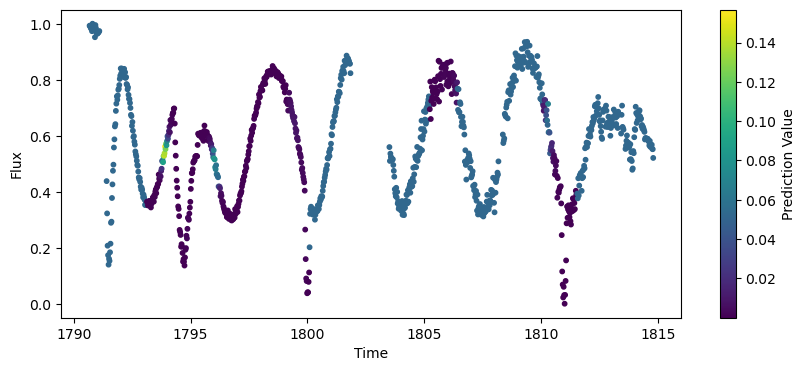

In [37]:
rows = results[results.ID == 394091813]
t = rows.iloc[0].time
f = rows.iloc[0].flux
p = rows.iloc[0].predictions  # This should be a list or array of same length as t and f

plt.figure(figsize=(10, 4))
sc = plt.scatter(t, f, c=p, cmap='viridis', s=10)  # Or use 'plasma', 'inferno', etc.
plt.colorbar(sc, label='Prediction Value')
plt.xlabel("Time")
plt.ylabel("Flux")
plt.show()


In [38]:
import os

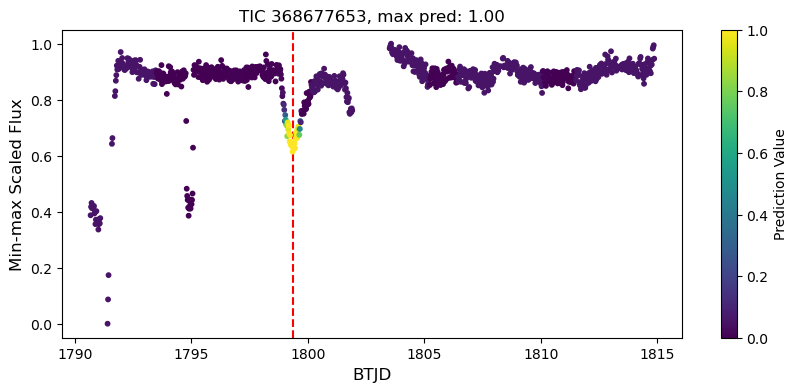

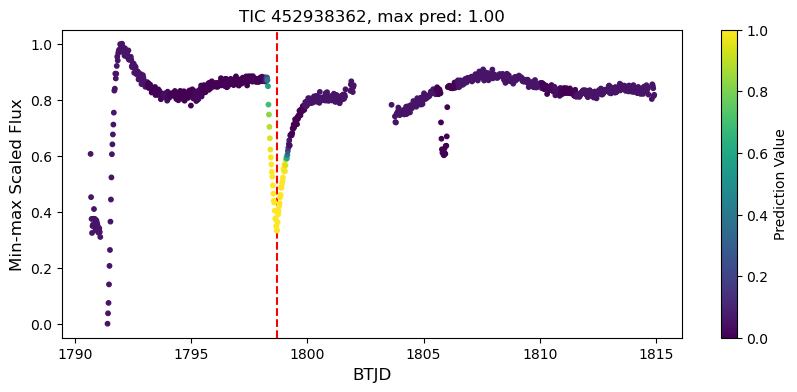

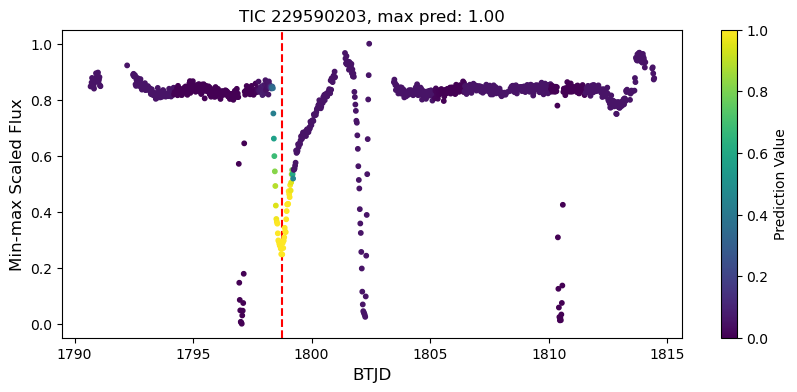

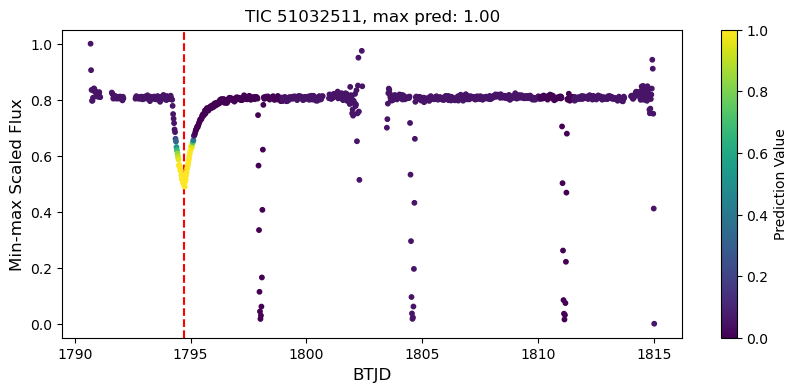

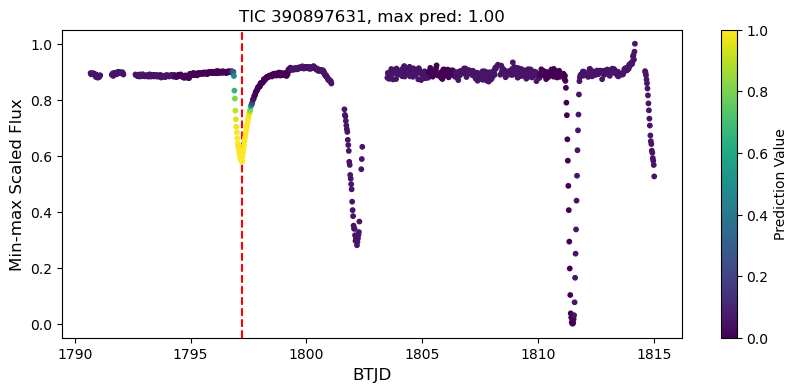

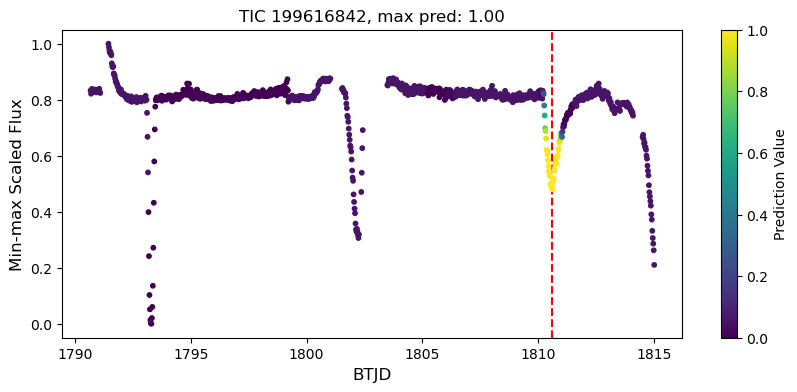

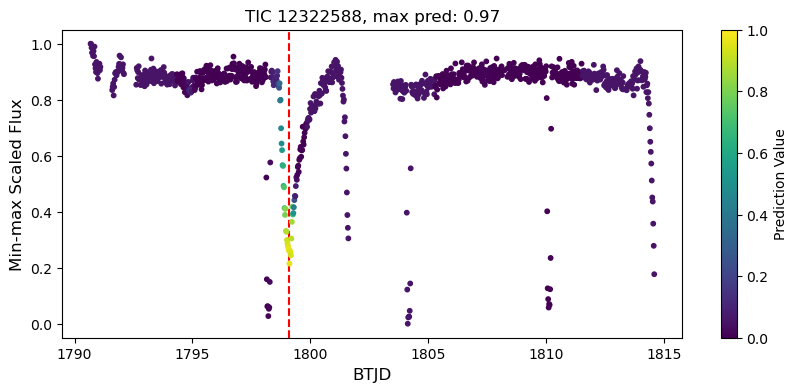

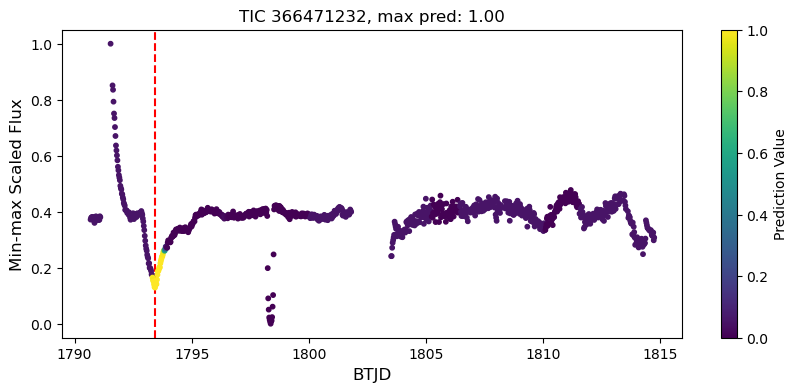

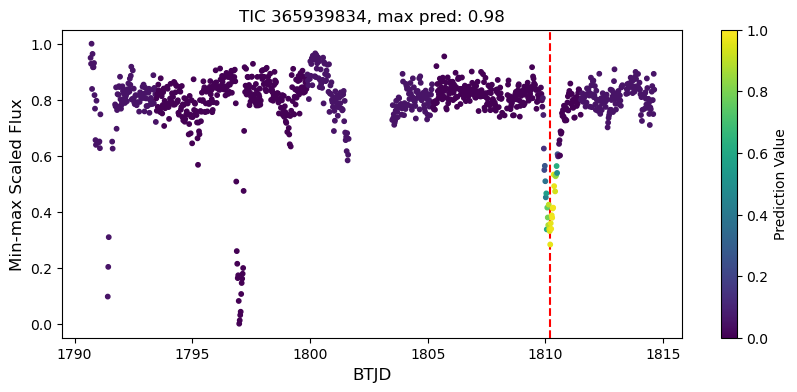

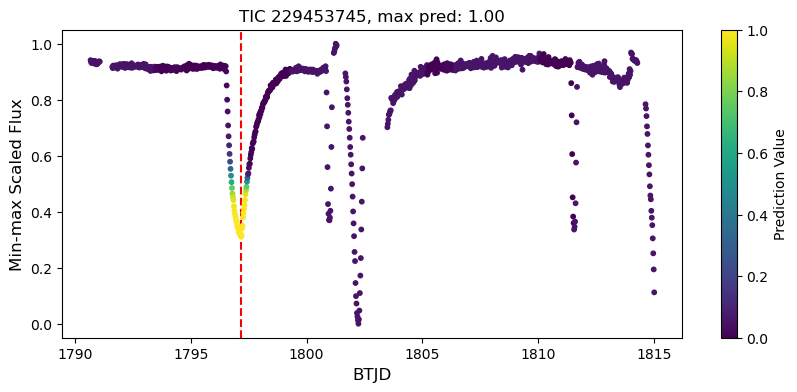

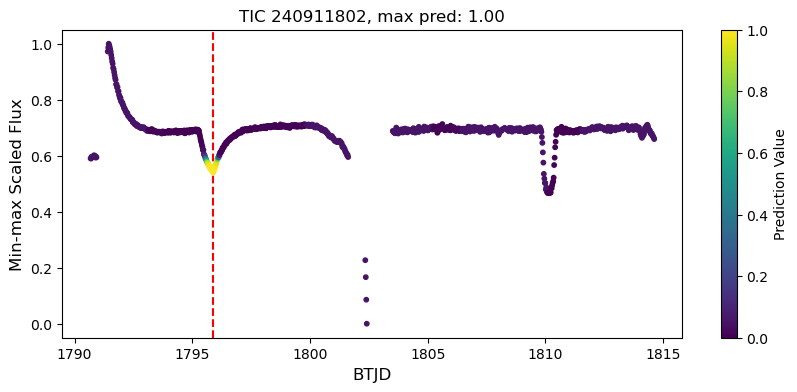

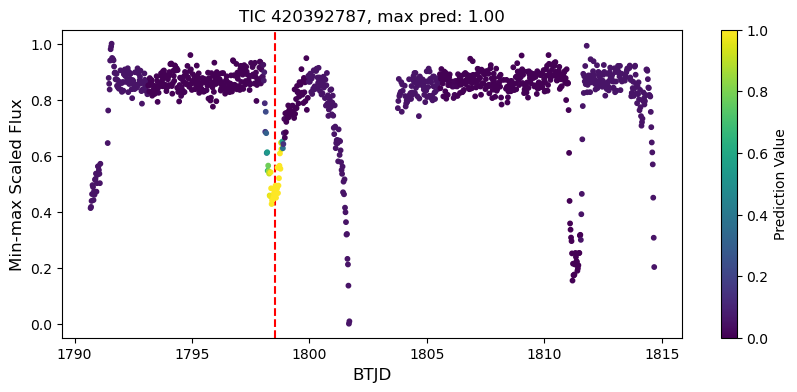

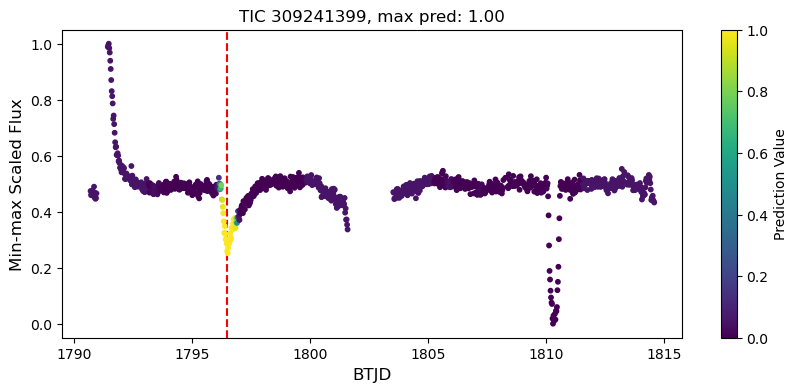

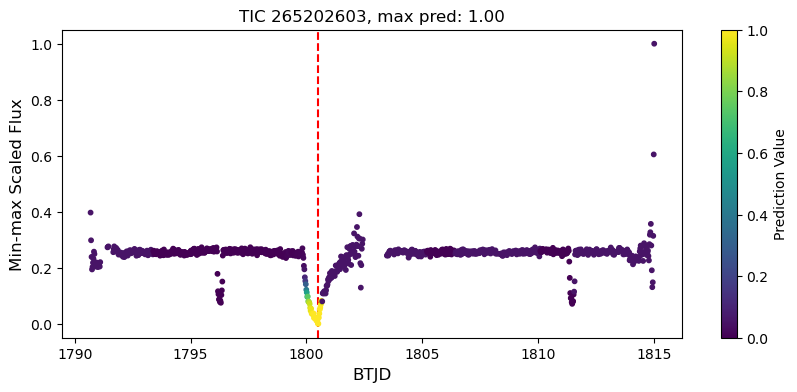

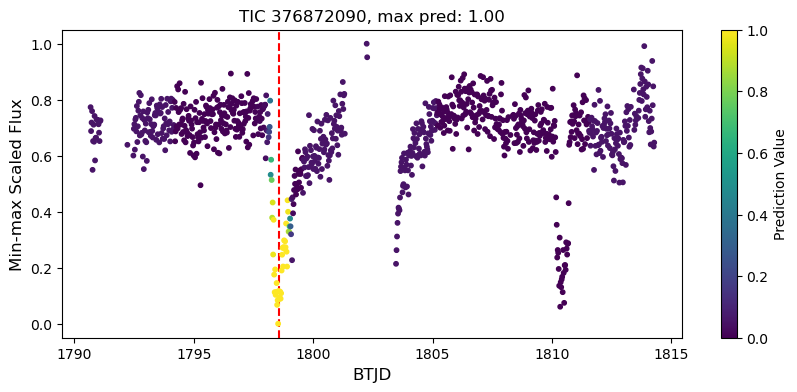

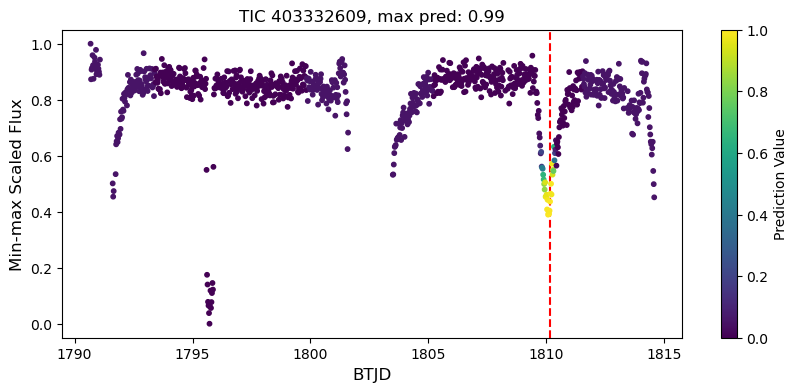

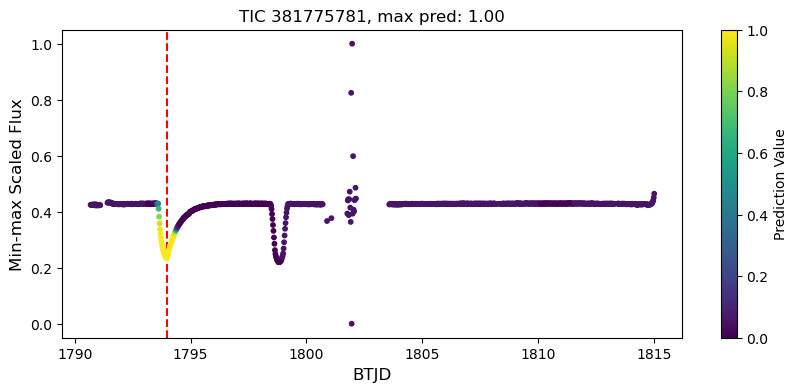

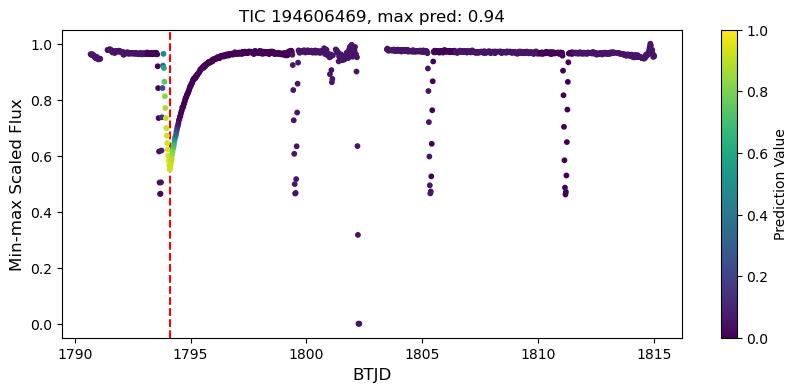

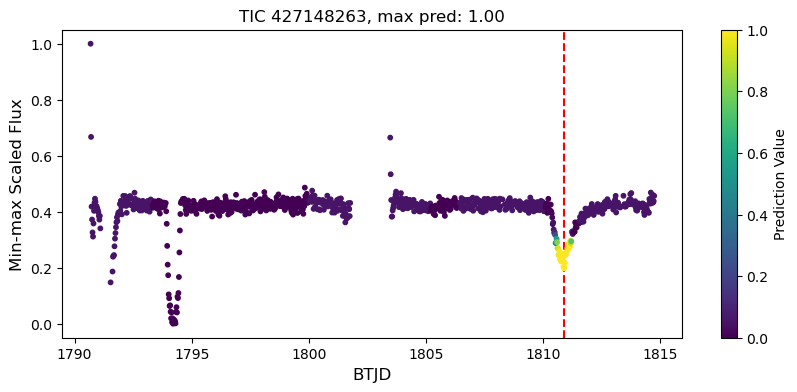

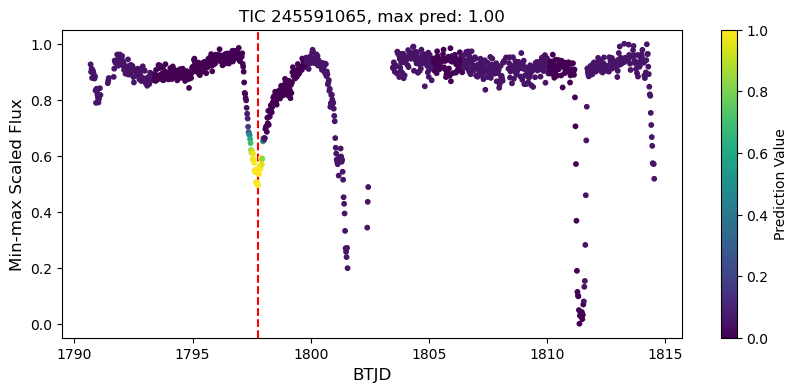

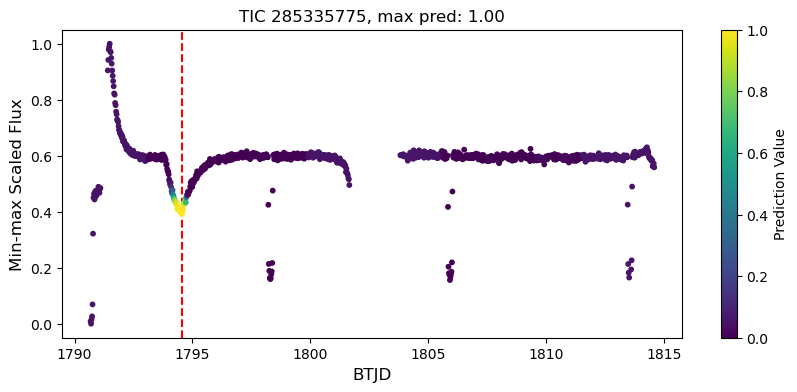

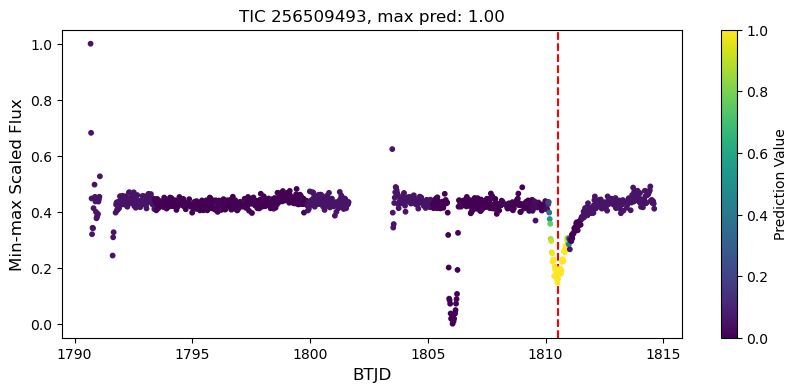

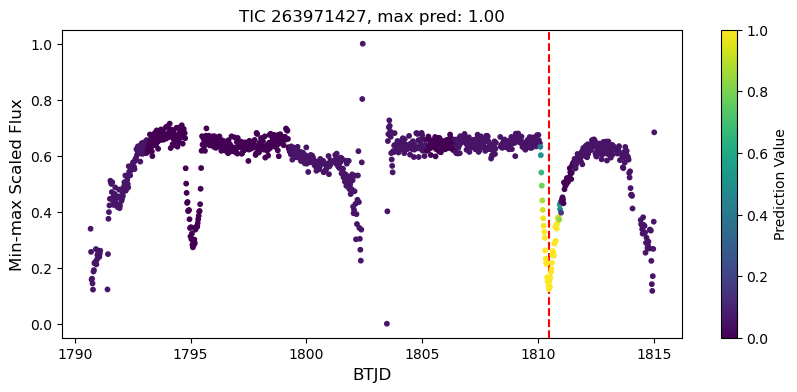

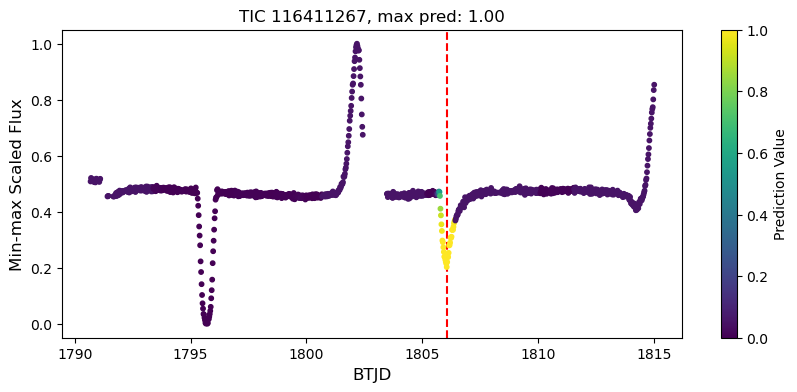

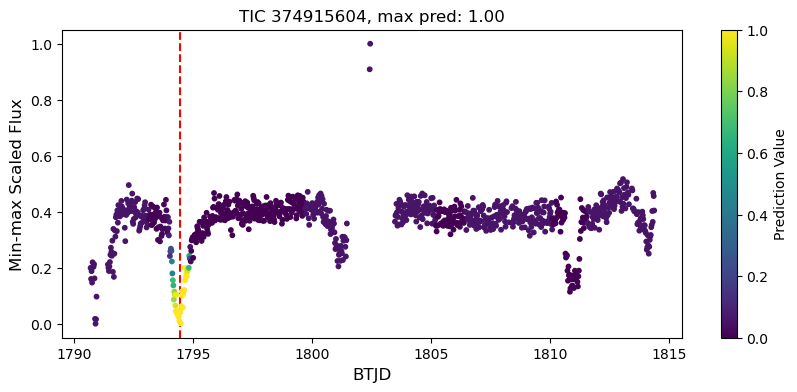

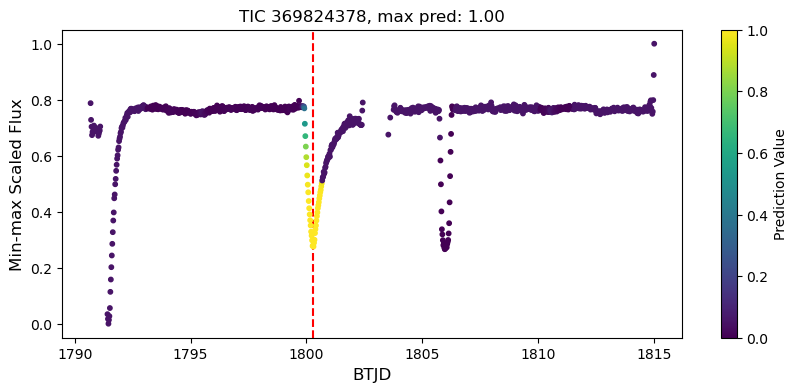

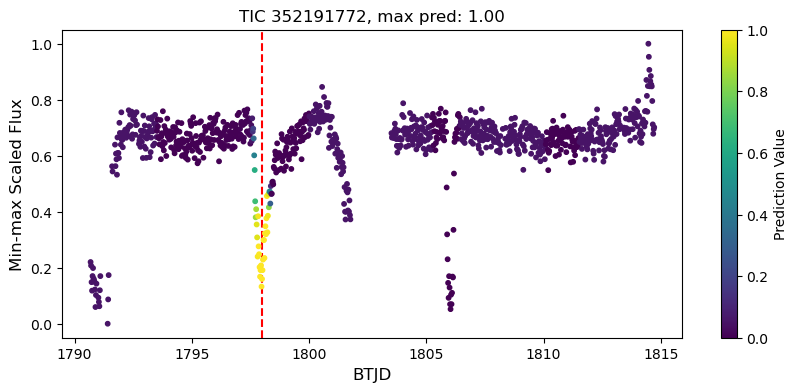

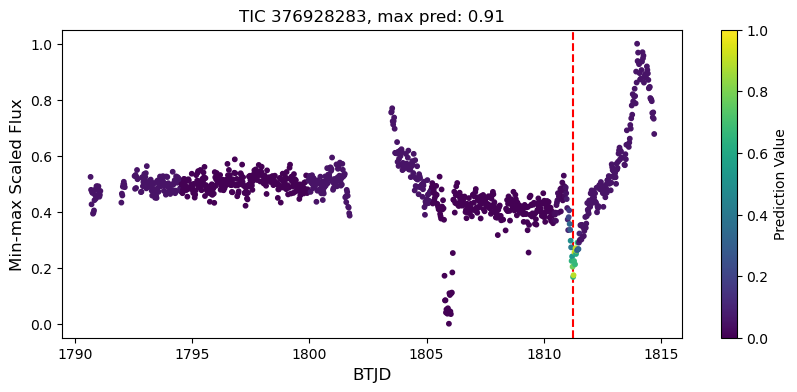

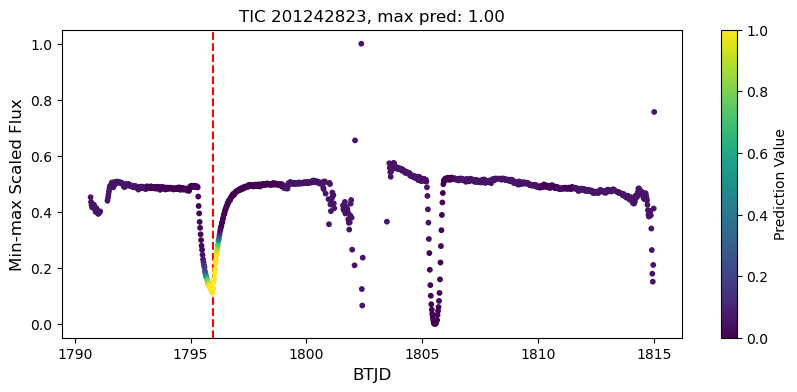

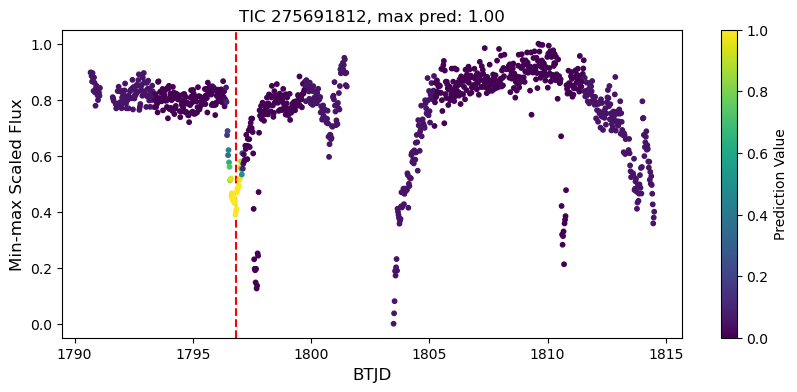

In [44]:
n = results[results.comet_recovered == 1]
os.makedirs('asym-sym-plots',exist_ok=True)

for i in n.index[0:30]:
    ID = n.iloc[i].ID
    time = n.iloc[i].time
    flux = n.iloc[i].flux
    pred = n.iloc[i].predictions 
    plt.figure(figsize=(10,4))
    plt.axvline(n.iloc[i].tpeak,linestyle='--',c='red',zorder=1 )
    sc = plt.scatter(time, flux, c=pred, cmap='viridis', s=10, vmin=0, vmax=1)  # Or use 'plasma', 'inferno', etc.
    plt.colorbar(sc, label='Prediction Value')
    plt.title(f'TIC {ID}, max pred: {np.max(pred):.2f}')
    plt.xlabel('BTJD',fontsize=12)
    plt.ylabel('Min-max Scaled Flux',fontsize=12)
    plt.savefig(f'asym-sym-plots/{ID}.png',dpi=300,bbox_inches='tight')
    plt.show()